# Example-13: Twiss from n-turn matrix

In [1]:
# Import

import numpy
import pandas
import torch

import sys
sys.path.append('..')

from harmonica.util import mod
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter
from harmonica.decomposition import Decomposition
from harmonica.model import Model
from harmonica.table import Table
from harmonica.twiss import Twiss

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())

True


In [2]:
# Set data type and device

dtype = torch.float64
device = 'cpu'

In [3]:
# In this example coupled twiss parameters are estimated from n-turn matrix

# Given (filtered) TbT data at each monitor location, twiss parameters at each probed monitor are estimated using x & y signals
# Other monitors are used to compute momentum at the probed monitor using model (or measured) transport matrix
# n-turn matrix is fitter using phase space data
# Twiss parameters are computed from symplectified n-turn matrix

# Note, in this example unfiltered TbT data is used
# Note, for computation of momenta at the probed monitor, only the next monitor is used
# Methods using several monitors are also avaliable

In [4]:
# Set model with errors

model = Model(path='../config.yaml', dtype=dtype, device=device)

# Set errors

model.make_error(1.0E-3, 0.5E-3, length=0.01)

# Set transport

model.make_transport(error=True, exact=False)

# Compute twiss (not used in generation of trajectories)

model.make_twiss()
print(model.is_stable)

# Set fractional tunes

mqx, mqy = model.out_tune_fractional

True


torch.Size([54, 1024, 4])

5.506395050e-07, 1.168602158e-18
9.325715556e-08, 2.970847222e-20



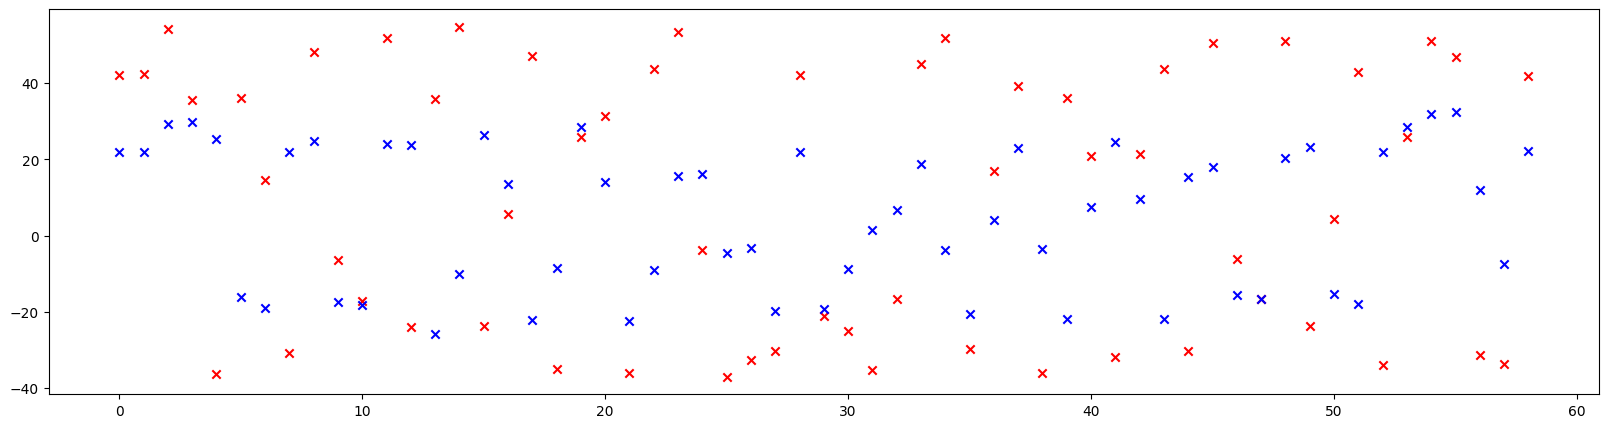

tensor(1.566782087898e+02, dtype=torch.float64)
tensor(1.457966765143e+02, dtype=torch.float64)



In [5]:
# Generate test trajectories

# Set initial condition

initial = torch.tensor([0.002, 0.0, 0.002, 0.0], dtype=dtype, device=device)

# Set number of iterations

length = 2**10

# Generate trajectories

trajectory =  model.make_trajectory(initial, length, error=True, transport=True)[model.monitor_index]
print(trajectory.shape)
print()

# Set x & y coordinates at each monitor location

x = trajectory[..., 0]
y = trajectory[..., 2]

# Compute reference invariant values using selected trajectory

# Set trajectory index

index = 0

# Compute invariants

from harmonica.parameterization import invariant
action_x, action_y = invariant(model.out_normal[model.monitor_index[index]], trajectory[index])

print(f'{action_x.mean().item():>12.9e}, {action_x.std().item():>12.9e}')
print(f'{action_y.mean().item():>12.9e}, {action_y.std().item():>12.9e}')
print()

action_x = action_x.mean()
action_y = action_y.mean()

# Compare model and real beta function values

from harmonica.parameterization import normal_to_wolski
from harmonica.parameterization import wolski_to_cs

cs_ax, cs_bx, cs_ay, cs_by = torch.stack([wolski_to_cs(w) for w in normal_to_wolski(model.out_normal)]).T

plt.figure(figsize=(20, 5))
plt.scatter(range(model.size), 100*(cs_bx - model.bx)/model.bx, color='red', marker='x')
plt.scatter(range(model.size), 100*(cs_by - model.by)/model.by, color='blue', marker='x')
plt.show()

error_x = (cs_bx[model.monitor_index] - model.bx[model.monitor_index]).abs().sum()
error_y = (cs_by[model.monitor_index] - model.by[model.monitor_index]).abs().sum()

print(error_x)
print(error_y)
print()

In [6]:
# Set free normalization matrix elements

N11 = model.out_normal[:, 0, 0][model.monitor_index]
N33 = model.out_normal[:, 2, 2][model.monitor_index]
N21 = model.out_normal[:, 1, 0][model.monitor_index]
N43 = model.out_normal[:, 3, 2][model.monitor_index]
N13 = model.out_normal[:, 0, 2][model.monitor_index]
N31 = model.out_normal[:, 2, 0][model.monitor_index]
N14 = model.out_normal[:, 0, 3][model.monitor_index]
N41 = model.out_normal[:, 3, 0][model.monitor_index]

# Using eight free elements other elements of normalization matrix can be computed from symplectic condition
# Note, N12 and N34 are fixed to zero values

from harmonica.parameterization import parametric_normal
print(torch.allclose(model.out_normal[model.monitor_index], torch.stack([parametric_normal(*free) for free in torch.stack([N11, N33, N21, N43, N13, N31, N14, N41]).T])))

True


In [7]:
# Generate TbT data

# Set noise values for each monitor location 

noise_x = 1.0E-6*(5.0 + 5.0*torch.rand(model.monitor_count, dtype=dtype, device=device))
noise_y = 1.0E-6*(5.0 + 5.0*torch.rand(model.monitor_count, dtype=dtype, device=device))

# Set window

win = Window.from_cosine(length, 1.0, dtype=dtype, device=device)

# Set TbT & add noise

X = Data.from_data(win, x)
X.add_noise(noise_x)
X.data.copy_(X.work)
X.reset()
print(X)

Y = Data.from_data(win, y)
Y.add_noise(noise_y)
Y.data.copy_(Y.work)
Y.reset()
print(Y)

Data(54, Window(1024, 'cosine_window', 1.0))
Data(54, Window(1024, 'cosine_window', 1.0))


In [8]:
# Compute frequency, amplitude and phase for x plane

# Estimate noise

flt = Filter(X)
_, sigma_x = flt.estimate_noise()

# Estimate (main) frequency

f = Frequency(X)
X.window_remove_mean()
X.window_apply()
f('parabola')
X.reset()
nux, sigma_nux = 1.0 - f.frequency.mean(), f.frequency.std()
print(f'mqx={mqx.item():12.9}')
print(f'nux={nux.item():12.9}, sigma_nux={sigma_nux.item():12.9}, error_nux={abs(mqx - nux).item():12.9}')

# Estimate amplitude & phase

d = Decomposition(X)

ax, sigma_ax, _ = d.harmonic_amplitude(nux, length=256, order=1.0, error=True, sigma_frequency=sigma_nux, shift=True, count=64, step=8, method='noise')
fx, sigma_fx, _ = d.harmonic_phase(nux, length=512, order=0.0, error=True, sigma_frequency=sigma_nux, shift=True, count=256, step=8, method='noise')

mqx=  0.57014924
nux= 0.570149192, sigma_nux=1.19383527e-07, error_nux=4.79383689e-08


In [9]:
# Compute frequency, amplitude and phase for y plane

# Estimate noise

flt = Filter(Y)
_, sigma_y = flt.estimate_noise()

# Estimate (main) frequency

f = Frequency(Y)
Y.window_remove_mean()
Y.window_apply()
f('parabola')
Y.reset()
nuy, sigma_nuy = 1.0 - f.frequency.mean(), f.frequency.std()
print(f'mqy={mqy.item():12.9}')
print(f'nuy={nuy.item():12.9}, sigma_nuy={sigma_nuy.item():12.9}, error_nuy={abs(mqy - nuy).item():12.9}')

# Estimate amplitude & phase

d = Decomposition(Y)

ay, sigma_ay, _ = d.harmonic_amplitude(nuy, length=256, order=1.0, error=True, sigma_frequency=sigma_nuy, shift=True, count=64, step=8, method='noise')
fy, sigma_fy, _ = d.harmonic_phase(nuy, length=512, order=0.0, error=True, sigma_frequency=sigma_nuy, shift=True, count=256, step=8, method='noise')

mqy= 0.622809994
nuy= 0.622810011, sigma_nuy=2.14956164e-07, error_nuy=1.68657867e-08


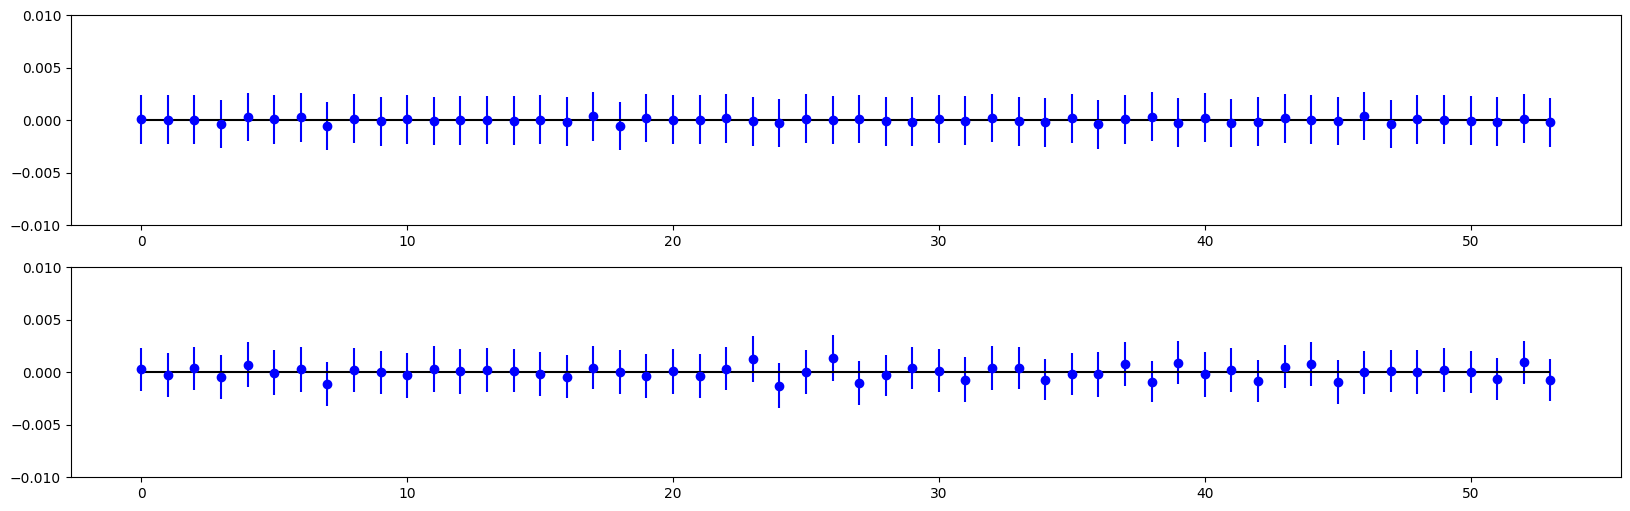

In [10]:
# Set table

table = Table(
    [name for name, kind in zip(model.name, model.kind) if kind == 'MONITOR'],
    nux, nuy, ax, ay, fx, fy, sigma_nux, sigma_nuy, sigma_ax, sigma_ay, sigma_fx, sigma_fy,
    x=X.data,
    y=Y.data,
    dtype=dtype, device=device)

# Compare phase advance between adjacent monitor locations

mux, muy = mod(model.out_advance.roll(1, 0).cumsum(0)[model.monitor_index].T, 2.0*numpy.pi)
mux, _ = Decomposition.phase_adjacent(mqx, mux)
muy, _ = Decomposition.phase_adjacent(mqy, muy)

plt.figure(figsize=(20, 3*2))

ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), (mux - table.phase_x).cpu().numpy(), yerr=table.sigma_x.cpu().numpy(), fmt=' ', marker='o', color='blue')
ax.hlines(0, 0, model.monitor_count - 1, colors='black')
ax.set_ylim(-1.0E-2, +1.0E-2)

ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), (muy - table.phase_y).cpu().numpy(), yerr=table.sigma_y.cpu().numpy(), fmt=' ', marker='o', color='blue')
ax.hlines(0, 0, model.monitor_count - 1, colors='black')
ax.set_ylim(-1.0E-2, +1.0E-2)

plt.show()

In [11]:
# Set twiss

twiss = Twiss(model, table)

In [12]:
%%time

# Estimate twiss from matrix
# Use first 512 turns from each signal to fit 1-turn matrix using 256 samples of length int(0.75*512)

# For each sample in each signal tunes and free normalization matrix elements are returned
# All zeros if matrix is unstable
# (nux, nuy, n11, n33, n21, n43, n13, n31, n14, n41)

data = twiss.get_twiss_from_matrix(1, 512, model.matrix, power=1, count=512, fraction=0.75)
print(data.shape)

torch.Size([54, 10, 512])
CPU times: user 45.5 s, sys: 12.3 s, total: 57.8 s
Wall time: 47.4 s


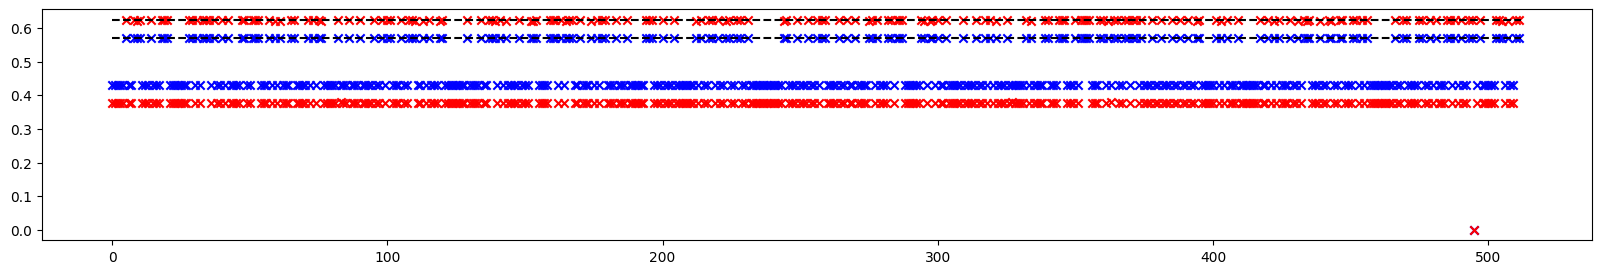

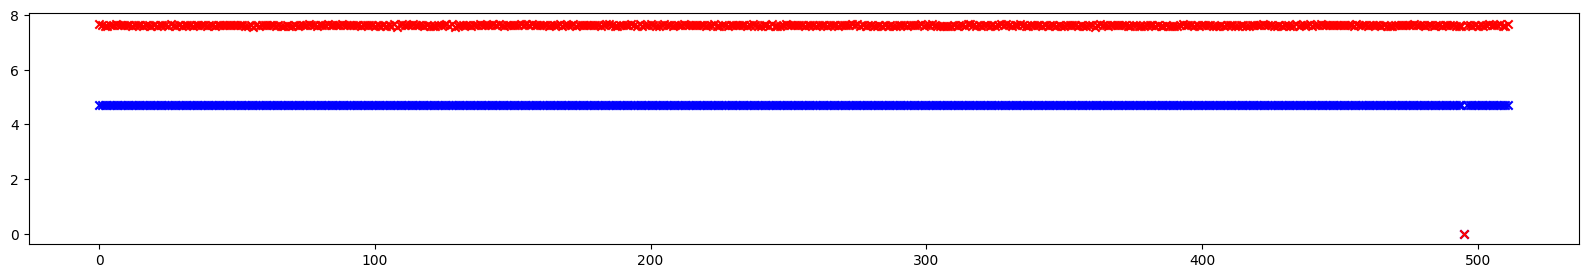

In [13]:
# In this example, fit from trajectories near IP is not accurate
# But 'good' sampes (tunewise) can be selected based on all tune data
# Note, twiss parameters are not necessarily bad for such samples

index = 25
plt.figure(figsize=(20, 3))
plt.scatter(range(512), data[index, 0].cpu().numpy(), color='blue', marker='x')
plt.scatter(range(512), data[index, 1].cpu().numpy(), color='red', marker='x')
plt.hlines([nux.item(), nuy.item()], 0, 512, linestyles='dashed', color='black')
plt.show()

plt.figure(figsize=(20, 3))
plt.scatter(range(512), data[index, 2].cpu().numpy(), color='blue', marker='x')
plt.scatter(range(512), data[index, 3].cpu().numpy(), color='red', marker='x')
plt.show()

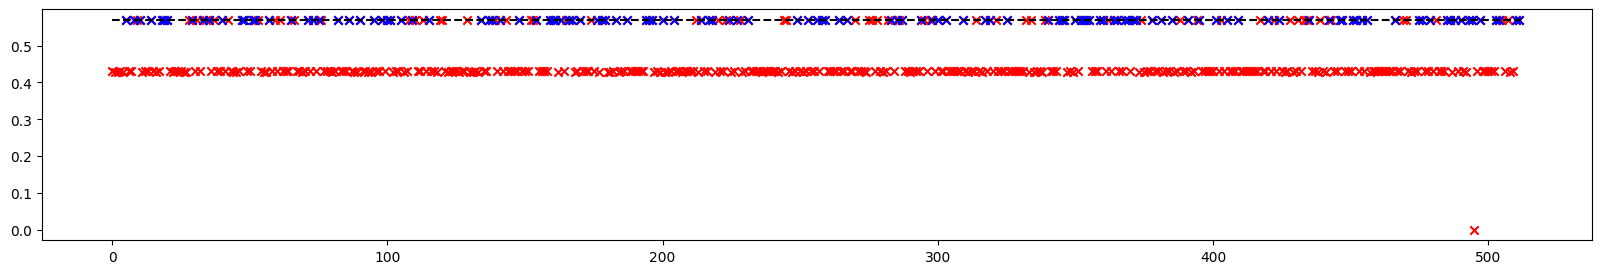

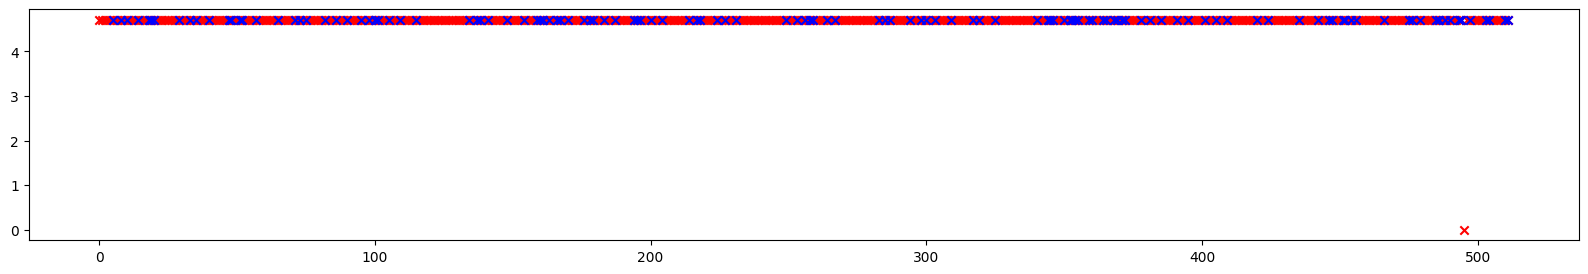

tensor(127)


In [14]:
# Generate tune mask

from harmonica.statistics import standardize
from harmonica.statistics import median, biweight_midvariance
from harmonica.anomaly import threshold

factor = torch.tensor(5.0, dtype=dtype, device=device)

tune_x = standardize(data[:, 0].flatten(), center_estimator=median, spread_estimator=biweight_midvariance)
mask_x = threshold(tune_x, -factor, +factor).squeeze().reshape(model.monitor_count, -1)

tune_y = standardize(data[:, 1].flatten(), center_estimator=median, spread_estimator=biweight_midvariance)
mask_y = threshold(tune_y, -factor, +factor).squeeze().reshape(model.monitor_count, -1)

index = 25
plt.figure(figsize=(20, 3))
plt.scatter(range(512), data[index, 0].cpu().numpy(), color='red', marker='x')
plt.scatter(torch.arange(512)[mask_x[index]*mask_y[index]], data[index, 0][mask_x[index]*mask_y[index]].cpu().numpy(), color='blue', marker='x')
plt.hlines([nux.item()], 0, 512, linestyles='dashed', color='black')
plt.show()

plt.figure(figsize=(20, 3))
plt.scatter(range(512), data[index, 2].cpu().numpy(), color='red', marker='x')
plt.scatter(torch.arange(512)[mask_x[index]*mask_y[index]], data[index, 2][mask_x[index]*mask_y[index]].cpu().numpy(), color='blue', marker='x')
plt.show()

print((mask_x[index]*mask_y[index]).sum())

In [15]:
# Process twiss

from harmonica.statistics import weighted_mean, weighted_variance

value_nux = weighted_mean(data[:, 0], weight=mask_x*mask_y)
value_nuy = weighted_mean(data[:, 1], weight=mask_x*mask_y)
value_n11 = weighted_mean(data[:, 2], weight=mask_x*mask_y)
value_n33 = weighted_mean(data[:, 3], weight=mask_x*mask_y)
value_n21 = weighted_mean(data[:, 4], weight=mask_x*mask_y)
value_n43 = weighted_mean(data[:, 5], weight=mask_x*mask_y)
value_n13 = weighted_mean(data[:, 6], weight=mask_x*mask_y)
value_n31 = weighted_mean(data[:, 7], weight=mask_x*mask_y)
value_n14 = weighted_mean(data[:, 8], weight=mask_x*mask_y)
value_n41 = weighted_mean(data[:, 9], weight=mask_x*mask_y)

error_nux = weighted_variance(data[:, 0], weight=mask_x*mask_y).sqrt()
error_nuy = weighted_variance(data[:, 1], weight=mask_x*mask_y).sqrt()
error_n11 = weighted_variance(data[:, 2], weight=mask_x*mask_y).sqrt()
error_n33 = weighted_variance(data[:, 3], weight=mask_x*mask_y).sqrt()
error_n21 = weighted_variance(data[:, 4], weight=mask_x*mask_y).sqrt()
error_n43 = weighted_variance(data[:, 5], weight=mask_x*mask_y).sqrt()
error_n13 = weighted_variance(data[:, 6], weight=mask_x*mask_y).sqrt()
error_n31 = weighted_variance(data[:, 7], weight=mask_x*mask_y).sqrt()
error_n14 = weighted_variance(data[:, 8], weight=mask_x*mask_y).sqrt()
error_n41 = weighted_variance(data[:, 9], weight=mask_x*mask_y).sqrt()

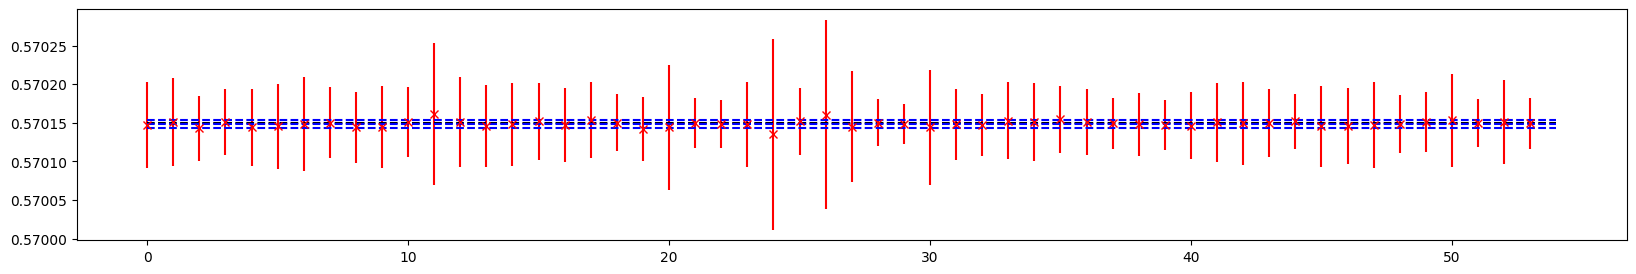

mqx=  0.57014924
nux= 0.570149192, sigma_nux=1.19383527e-07, error_nux=4.79383689e-08
nux=  0.57014878, sigma_nux=5.35614499e-06, error_nux=4.60261402e-07


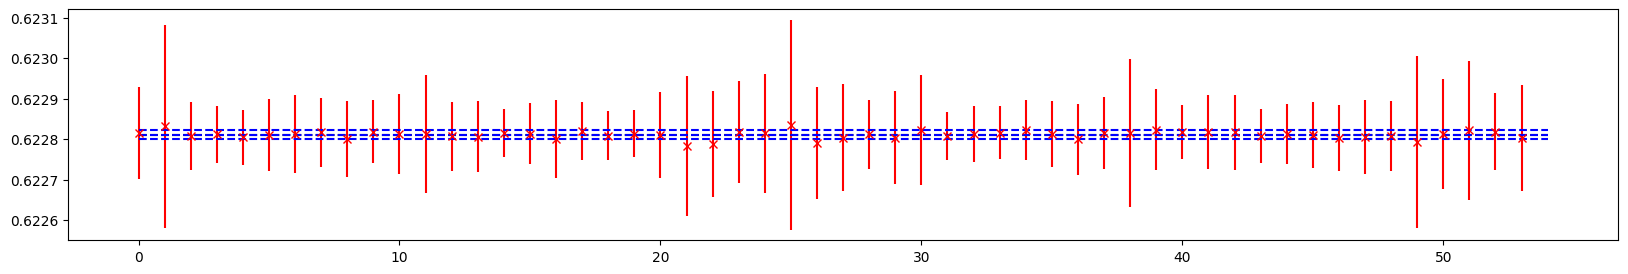

mqy= 0.622809994
nuy= 0.622810011, sigma_nuy=2.14956164e-07, error_nuy=1.68657867e-08
nuy= 0.622811506, sigma_nuy=1.18041712e-05, error_nuy=1.51266678e-06


In [16]:
# Compare tunes

value = weighted_mean(value_nux, error_nux)
error = weighted_variance(value_nux, error_nux).sqrt()

plt.figure(figsize=(20, 3))
plt.errorbar(range(model.monitor_count), value_nux, yerr=error_nux, fmt=' ', color='red', marker='x')
plt.hlines(nux.item(), 0, model.monitor_count, linestyles='dashed', color='black')
plt.hlines([(value - error).item(), value.item(), (value + error).item()], 0, model.monitor_count, linestyles='dashed', color='blue')
plt.show()

print(f'mqx={mqx.item():12.9}')
print(f'nux={nux.item():12.9}, sigma_nux={sigma_nux.item():12.9}, error_nux={abs(mqx - nux).item():12.9}')
print(f'nux={value.item():12.9}, sigma_nux={error.item():12.9}, error_nux={abs(mqx - value).item():12.9}')

value = weighted_mean(value_nuy, error_nuy)
error = weighted_variance(value_nuy, error_nuy).sqrt()

plt.figure(figsize=(20, 3))
plt.errorbar(range(model.monitor_count), value_nuy, yerr=error_nuy, fmt=' ', color='red', marker='x')
plt.hlines(nuy.item(), 0, model.monitor_count, linestyles='dashed', color='black')
plt.hlines([(value - error).item(), value.item(), (value + error).item()], 0, model.monitor_count, linestyles='dashed', color='blue')
plt.show()

print(f'mqy={mqy.item():12.9}')
print(f'nuy={nuy.item():12.9}, sigma_nuy={sigma_nuy.item():12.9}, error_nuy={abs(mqy - nuy).item():12.9}')
print(f'nuy={value.item():12.9}, sigma_nuy={error.item():12.9}, error_nuy={abs(mqy - value).item():12.9}')

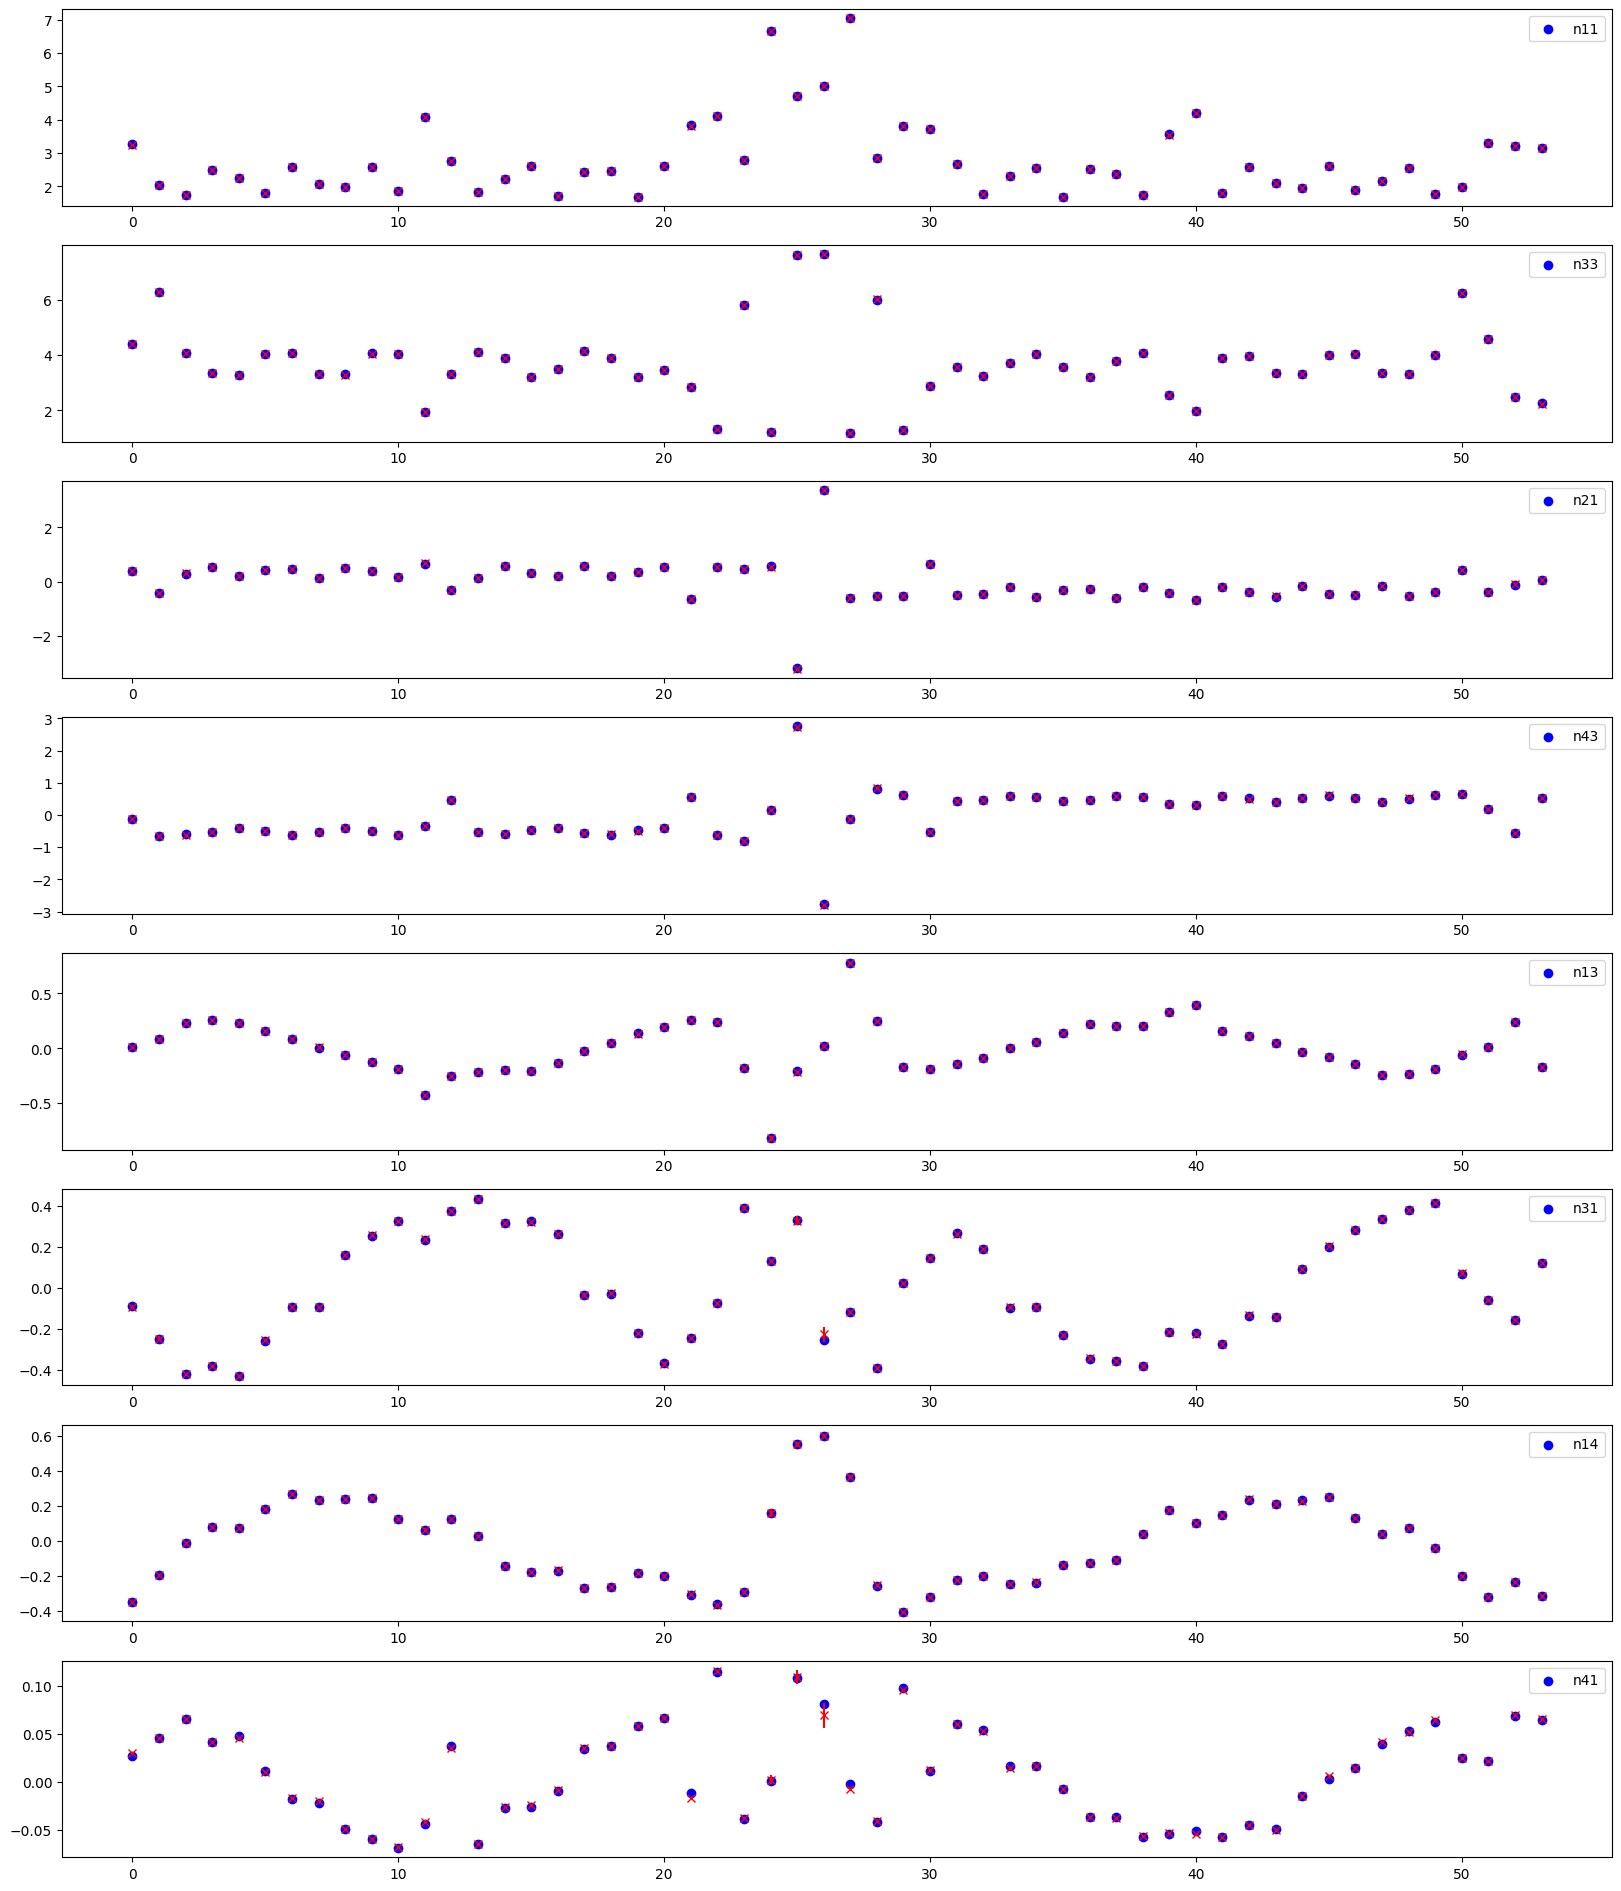

tensor(1.448308453475e-01, dtype=torch.float64)
tensor(1.747087808040e-01, dtype=torch.float64)
tensor(1.207024957145e-01, dtype=torch.float64)
tensor(1.851698972283e-01, dtype=torch.float64)
tensor(4.721962246221e-02, dtype=torch.float64)
tensor(1.035670499924e-01, dtype=torch.float64)
tensor(2.875646974170e-02, dtype=torch.float64)
tensor(7.188893728564e-02, dtype=torch.float64)


In [17]:
# Compare normalization matrix elements with exact values

plt.figure(figsize=(20, 8*3))

ax = plt.subplot(811)
ax.scatter(range(model.monitor_count), N11, color='blue', marker='o', label='n11')
ax.errorbar(range(model.monitor_count), value_n11, yerr=error_n11, fmt=' ', color='red', marker='x')
ax.legend()

ax = plt.subplot(812)
ax.scatter(range(model.monitor_count), N33, color='blue', marker='o', label='n33')
ax.errorbar(range(model.monitor_count), value_n33, yerr=error_n33, fmt=' ', color='red', marker='x')
ax.legend()

ax = plt.subplot(813)
ax.scatter(range(model.monitor_count), N21, color='blue', marker='o', label='n21')
ax.errorbar(range(model.monitor_count), value_n21, yerr=error_n21, fmt=' ', color='red', marker='x')
ax.legend()

ax = plt.subplot(814)
ax.scatter(range(model.monitor_count), N43, color='blue', marker='o', label='n43')
ax.errorbar(range(model.monitor_count), value_n43, yerr=error_n43, fmt=' ', color='red', marker='x')
ax.legend()

ax = plt.subplot(815)
ax.scatter(range(model.monitor_count), N13, color='blue', marker='o', label='n13')
ax.errorbar(range(model.monitor_count), value_n13, yerr=error_n13, fmt=' ', color='red', marker='x')
ax.legend()

ax = plt.subplot(816)
ax.scatter(range(model.monitor_count), N31, color='blue', marker='o', label='n31')
ax.errorbar(range(model.monitor_count), value_n31, yerr=error_n31, fmt=' ', color='red', marker='x')
ax.legend()

ax = plt.subplot(817)
ax.scatter(range(model.monitor_count), N14, color='blue', marker='o', label='n14')
ax.errorbar(range(model.monitor_count), value_n14, yerr=error_n14, fmt=' ', color='red', marker='x')
ax.legend()

ax = plt.subplot(818)
ax.scatter(range(model.monitor_count), N41, color='blue', marker='o', label='n41')
ax.errorbar(range(model.monitor_count), value_n41, yerr=error_n41, fmt=' ', color='red', marker='x')
ax.legend()

plt.show()

print((N11 - value_n11).abs().sum())
print((N33 - value_n33).abs().sum())
print((N21 - value_n21).abs().sum())
print((N43 - value_n43).abs().sum())
print((N13 - value_n13).abs().sum())
print((N31 - value_n31).abs().sum())
print((N14 - value_n14).abs().sum())
print((N41 - value_n41).abs().sum())

In [18]:
%%time

# Estimate twiss from matrix
# Use first 512 turns from each signal to fit 2-turn matrix using 256 samples of length int(0.75*512)

# For each sample in each signal tunes and free normalization matrix elements are returned
# All zeros if matrix is unstable
# (nux, nuy, n11, n33, n21, n43, n13, n31, n14, n41)

data = twiss.get_twiss_from_matrix(1, 512, model.matrix, power=2, count=512, fraction=0.75)
print(data.shape)

torch.Size([54, 10, 512])
CPU times: user 47 s, sys: 12.1 s, total: 59.1 s
Wall time: 48.9 s


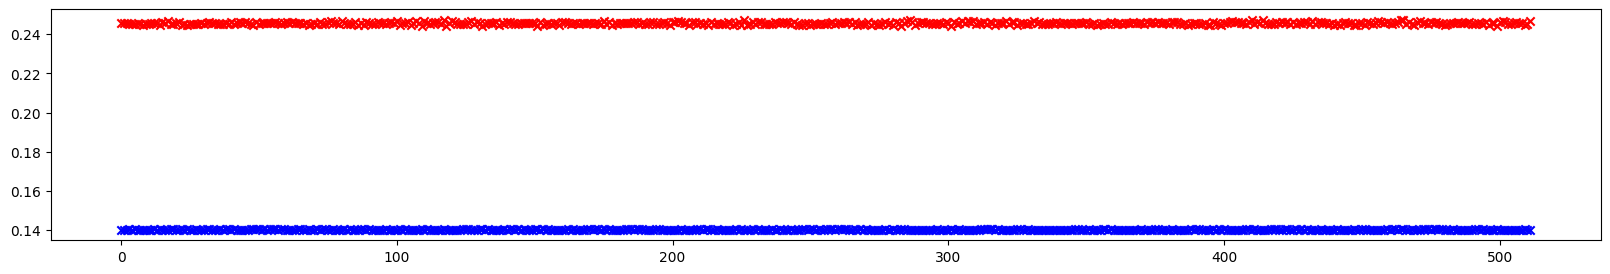

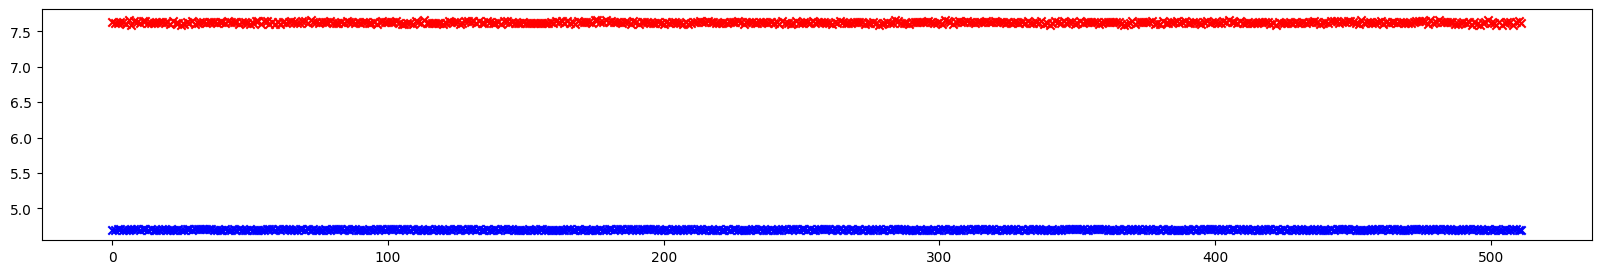

In [19]:
# In this example, fit from trajectories near IP with 2-turn matrix is more accurate

index = 25
plt.figure(figsize=(20, 3))
plt.scatter(range(512), data[index, 0].cpu().numpy(), color='blue', marker='x')
plt.scatter(range(512), data[index, 1].cpu().numpy(), color='red', marker='x')
plt.show()

plt.figure(figsize=(20, 3))
plt.scatter(range(512), data[index, 2].cpu().numpy(), color='blue', marker='x')
plt.scatter(range(512), data[index, 3].cpu().numpy(), color='red', marker='x')
plt.show()

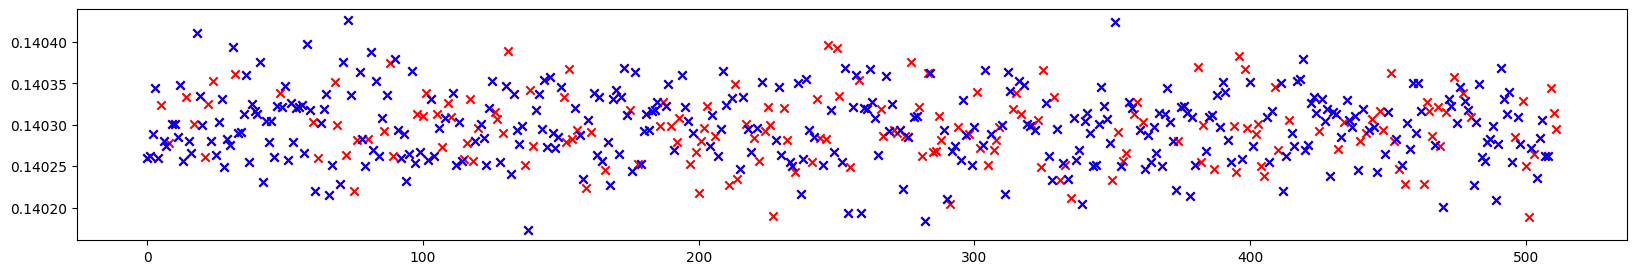

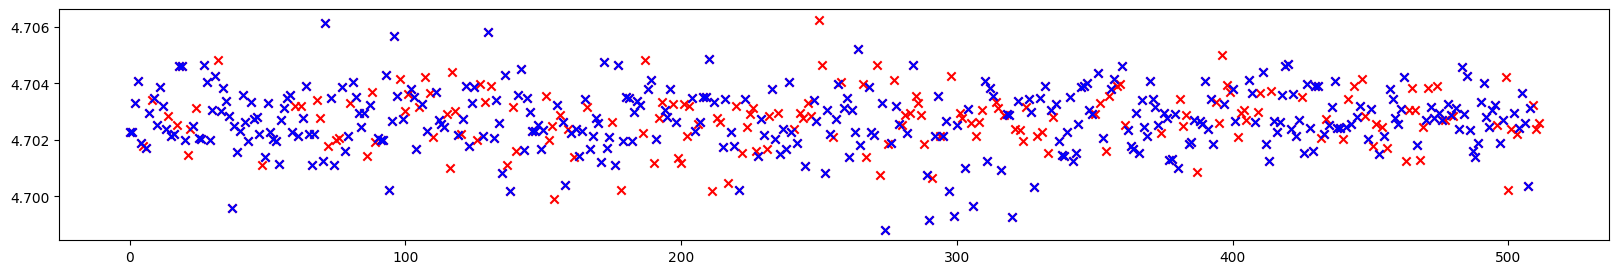

tensor(342)


In [20]:
# Generate tune mask

from harmonica.statistics import standardize
from harmonica.statistics import median, biweight_midvariance
from harmonica.anomaly import threshold

factor = torch.tensor(5.0, dtype=dtype, device=device)

tune_x = standardize(data[:, 0].flatten(), center_estimator=median, spread_estimator=biweight_midvariance)
mask_x = threshold(tune_x, -factor, +factor).squeeze().reshape(model.monitor_count, -1)

tune_y = standardize(data[:, 1].flatten(), center_estimator=median, spread_estimator=biweight_midvariance)
mask_y = threshold(tune_y, -factor, +factor).squeeze().reshape(model.monitor_count, -1)

index = 25
plt.figure(figsize=(20, 3))
plt.scatter(range(512), data[index, 0].cpu().numpy(), color='red', marker='x')
plt.scatter(torch.arange(512)[mask_x[index]*mask_y[index]], data[index, 0][mask_x[index]*mask_y[index]].cpu().numpy(), color='blue', marker='x')
plt.show()

plt.figure(figsize=(20, 3))
plt.scatter(range(512), data[index, 2].cpu().numpy(), color='red', marker='x')
plt.scatter(torch.arange(512)[mask_x[index]*mask_y[index]], data[index, 2][mask_x[index]*mask_y[index]].cpu().numpy(), color='blue', marker='x')
plt.show()

print((mask_x[index]*mask_y[index]).sum())

In [21]:
# Process twiss

from harmonica.statistics import weighted_mean, weighted_variance

value_nux = weighted_mean(data[:, 0], weight=mask_x*mask_y)
value_nuy = weighted_mean(data[:, 1], weight=mask_x*mask_y)
value_n11 = weighted_mean(data[:, 2], weight=mask_x*mask_y)
value_n33 = weighted_mean(data[:, 3], weight=mask_x*mask_y)
value_n21 = weighted_mean(data[:, 4], weight=mask_x*mask_y)
value_n43 = weighted_mean(data[:, 5], weight=mask_x*mask_y)
value_n13 = weighted_mean(data[:, 6], weight=mask_x*mask_y)
value_n31 = weighted_mean(data[:, 7], weight=mask_x*mask_y)
value_n14 = weighted_mean(data[:, 8], weight=mask_x*mask_y)
value_n41 = weighted_mean(data[:, 9], weight=mask_x*mask_y)

error_nux = weighted_variance(data[:, 0], weight=mask_x*mask_y).sqrt()
error_nuy = weighted_variance(data[:, 1], weight=mask_x*mask_y).sqrt()
error_n11 = weighted_variance(data[:, 2], weight=mask_x*mask_y).sqrt()
error_n33 = weighted_variance(data[:, 3], weight=mask_x*mask_y).sqrt()
error_n21 = weighted_variance(data[:, 4], weight=mask_x*mask_y).sqrt()
error_n43 = weighted_variance(data[:, 5], weight=mask_x*mask_y).sqrt()
error_n13 = weighted_variance(data[:, 6], weight=mask_x*mask_y).sqrt()
error_n31 = weighted_variance(data[:, 7], weight=mask_x*mask_y).sqrt()
error_n14 = weighted_variance(data[:, 8], weight=mask_x*mask_y).sqrt()
error_n41 = weighted_variance(data[:, 9], weight=mask_x*mask_y).sqrt()

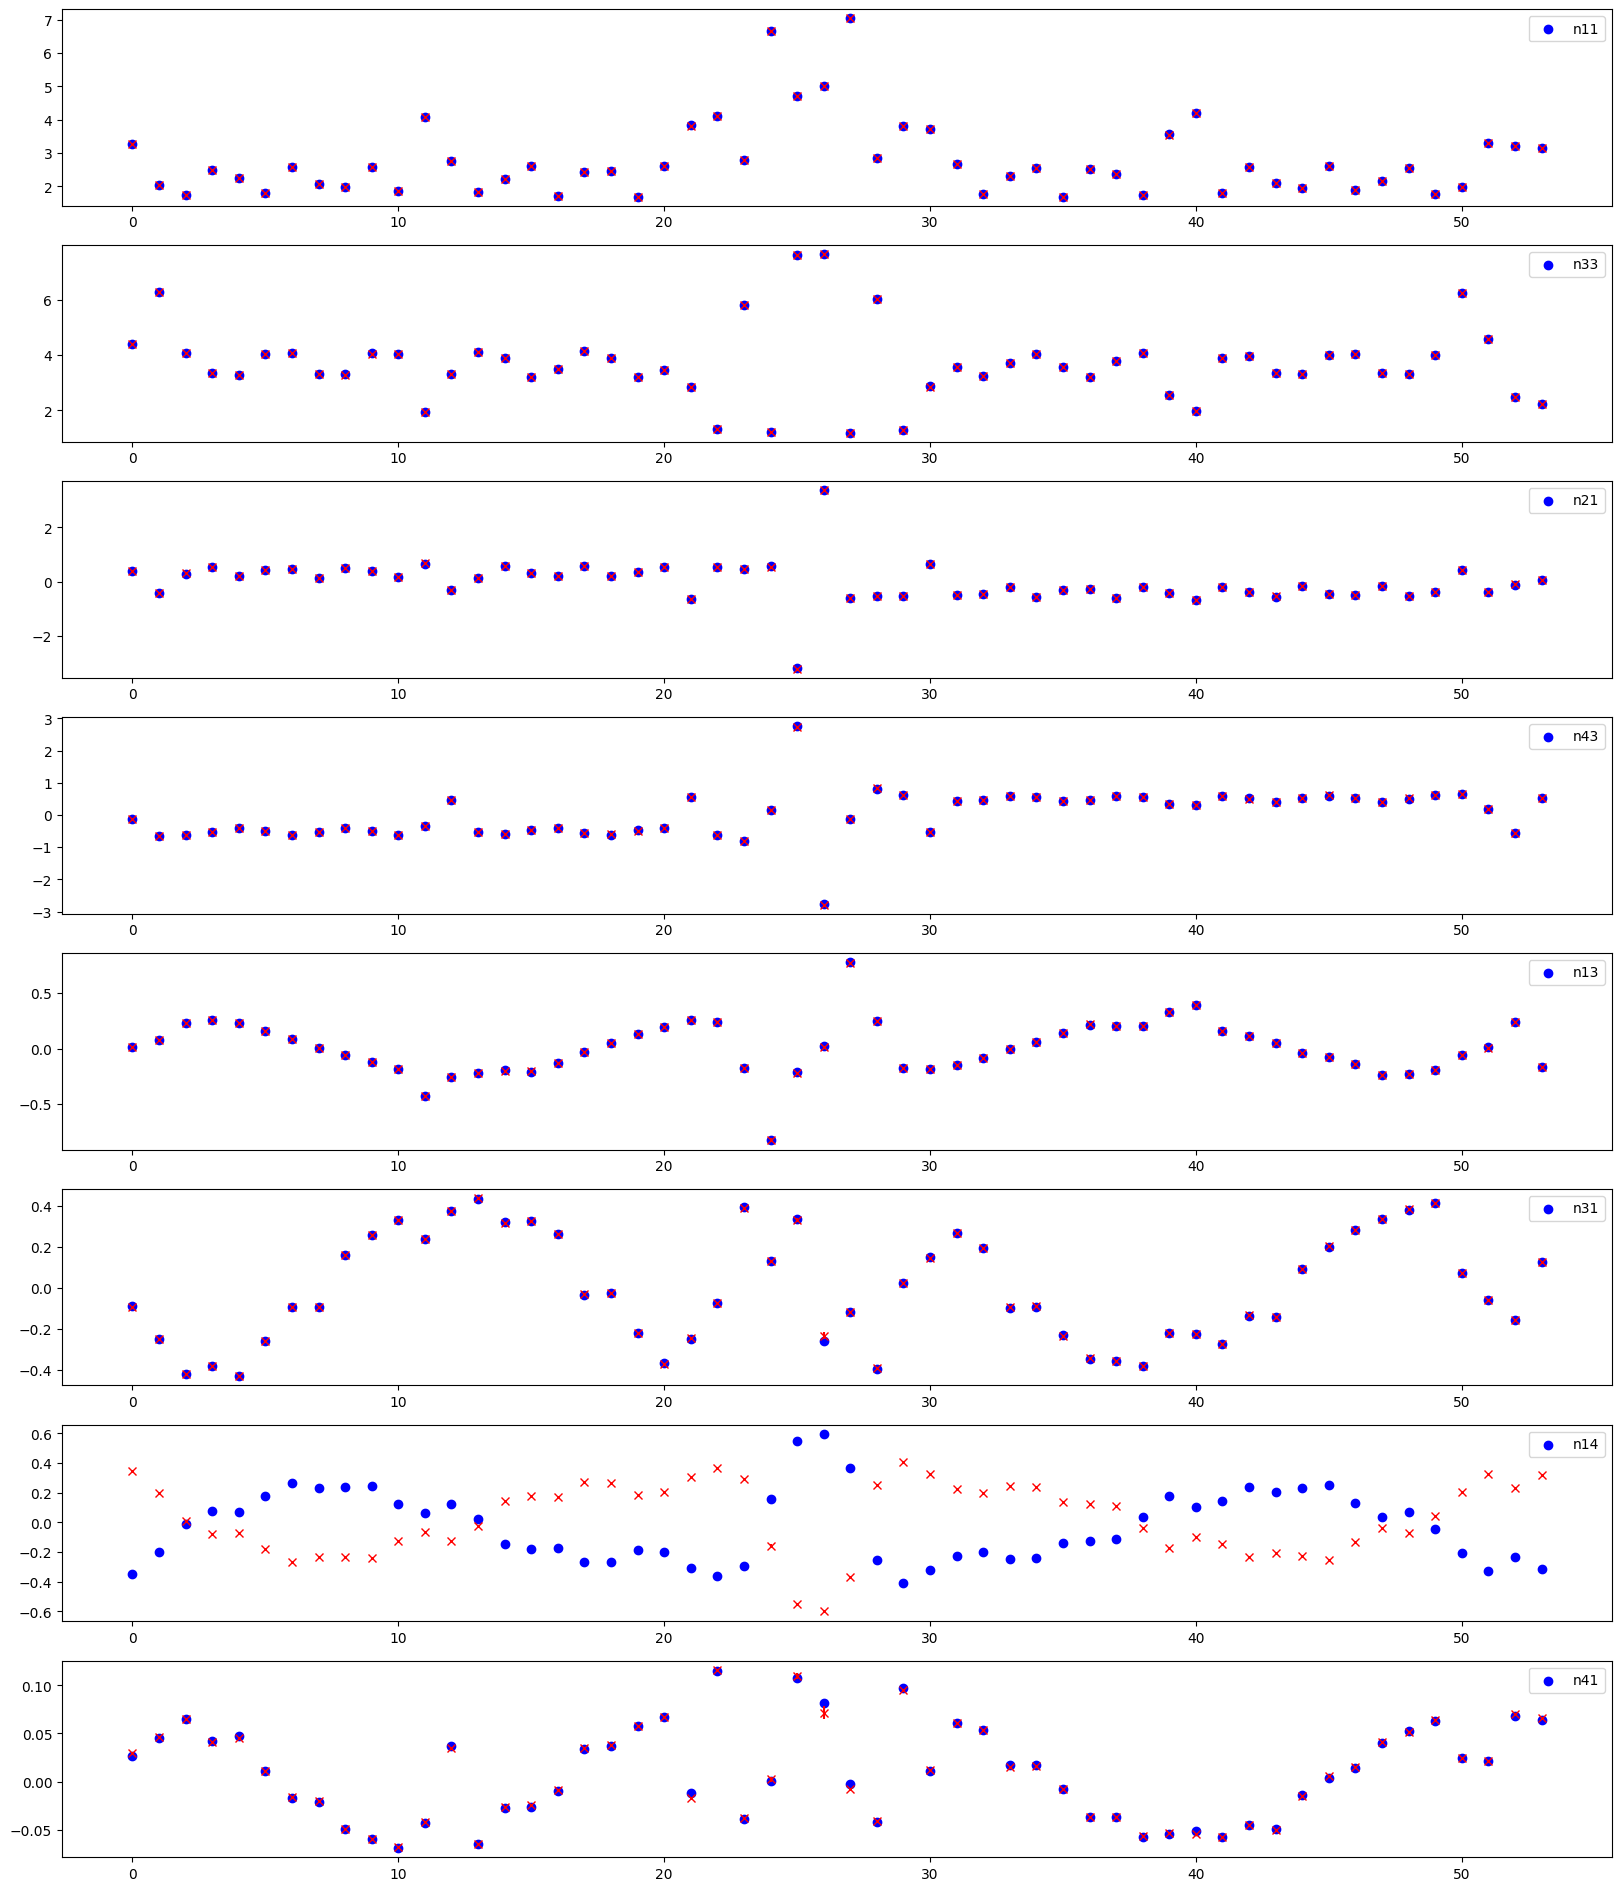

tensor(1.469280060079e-01, dtype=torch.float64)
tensor(1.759456752535e-01, dtype=torch.float64)
tensor(1.202595919021e-01, dtype=torch.float64)
tensor(1.839700708781e-01, dtype=torch.float64)
tensor(4.885148054488e-02, dtype=torch.float64)
tensor(9.354426968911e-02, dtype=torch.float64)
tensor(2.256827207827e+01, dtype=torch.float64)
tensor(7.057490092407e-02, dtype=torch.float64)


In [22]:
# Compare normalization matrix elements with exact values

plt.figure(figsize=(20, 8*3))

ax = plt.subplot(811)
ax.scatter(range(model.monitor_count), N11, color='blue', marker='o', label='n11')
ax.errorbar(range(model.monitor_count), value_n11, yerr=error_n11, fmt=' ', color='red', marker='x')
ax.legend()

ax = plt.subplot(812)
ax.scatter(range(model.monitor_count), N33, color='blue', marker='o', label='n33')
ax.errorbar(range(model.monitor_count), value_n33, yerr=error_n33, fmt=' ', color='red', marker='x')
ax.legend()

ax = plt.subplot(813)
ax.scatter(range(model.monitor_count), N21, color='blue', marker='o', label='n21')
ax.errorbar(range(model.monitor_count), value_n21, yerr=error_n21, fmt=' ', color='red', marker='x')
ax.legend()

ax = plt.subplot(814)
ax.scatter(range(model.monitor_count), N43, color='blue', marker='o', label='n43')
ax.errorbar(range(model.monitor_count), value_n43, yerr=error_n43, fmt=' ', color='red', marker='x')
ax.legend()

ax = plt.subplot(815)
ax.scatter(range(model.monitor_count), N13, color='blue', marker='o', label='n13')
ax.errorbar(range(model.monitor_count), value_n13, yerr=error_n13, fmt=' ', color='red', marker='x')
ax.legend()

ax = plt.subplot(816)
ax.scatter(range(model.monitor_count), N31, color='blue', marker='o', label='n31')
ax.errorbar(range(model.monitor_count), value_n31, yerr=error_n31, fmt=' ', color='red', marker='x')
ax.legend()

ax = plt.subplot(817)
ax.scatter(range(model.monitor_count), N14, color='blue', marker='o', label='n14')
ax.errorbar(range(model.monitor_count), value_n14, yerr=error_n14, fmt=' ', color='red', marker='x')
ax.legend()

ax = plt.subplot(818)
ax.scatter(range(model.monitor_count), N41, color='blue', marker='o', label='n41')
ax.errorbar(range(model.monitor_count), value_n41, yerr=error_n41, fmt=' ', color='red', marker='x')
ax.legend()

plt.show()

print((N11 - value_n11).abs().sum())
print((N33 - value_n33).abs().sum())
print((N21 - value_n21).abs().sum())
print((N43 - value_n43).abs().sum())
print((N13 - value_n13).abs().sum())
print((N31 - value_n31).abs().sum())
print((N14 - value_n14).abs().sum())
print((N41 - value_n41).abs().sum())

In [23]:
%%time

# Twiss at virtual locations (from virtual orbits)
# Note, method='lstsq'

data = twiss.get_twiss_from_matrix(1, 
                                   512,
                                   model.matrix,
                                   power=2,
                                   method='lstsq',
                                   limit=2,
                                   phony=True,
                                   count=512, 
                                   fraction=0.75)
print(data.shape)
print(model.virtual_count)

torch.Size([5, 10, 512])
5
CPU times: user 5.39 s, sys: 1.36 s, total: 6.75 s
Wall time: 5.49 s


In [24]:
# Process twiss

from harmonica.statistics import standardize
from harmonica.statistics import median, biweight_midvariance
from harmonica.anomaly import threshold

factor = torch.tensor(5.0, dtype=dtype, device=device)

tune_x = standardize(data[:, 0].flatten(), center_estimator=median, spread_estimator=biweight_midvariance)
mask_x = threshold(tune_x, -factor, +factor).squeeze().reshape(model.virtual_count, -1)

tune_y = standardize(data[:, 1].flatten(), center_estimator=median, spread_estimator=biweight_midvariance)
mask_y = threshold(tune_y, -factor, +factor).squeeze().reshape(model.virtual_count, -1)

from harmonica.statistics import weighted_mean, weighted_variance

value_nux = weighted_mean(data[:, 0], weight=mask_x*mask_y)
value_nuy = weighted_mean(data[:, 1], weight=mask_x*mask_y)
value_n11 = weighted_mean(data[:, 2], weight=mask_x*mask_y)
value_n33 = weighted_mean(data[:, 3], weight=mask_x*mask_y)
value_n21 = weighted_mean(data[:, 4], weight=mask_x*mask_y)
value_n43 = weighted_mean(data[:, 5], weight=mask_x*mask_y)
value_n13 = weighted_mean(data[:, 6], weight=mask_x*mask_y)
value_n31 = weighted_mean(data[:, 7], weight=mask_x*mask_y)
value_n14 = weighted_mean(data[:, 8], weight=mask_x*mask_y)
value_n41 = weighted_mean(data[:, 9], weight=mask_x*mask_y)

error_nux = weighted_variance(data[:, 0], weight=mask_x*mask_y).sqrt()
error_nuy = weighted_variance(data[:, 1], weight=mask_x*mask_y).sqrt()
error_n11 = weighted_variance(data[:, 2], weight=mask_x*mask_y).sqrt()
error_n33 = weighted_variance(data[:, 3], weight=mask_x*mask_y).sqrt()
error_n21 = weighted_variance(data[:, 4], weight=mask_x*mask_y).sqrt()
error_n43 = weighted_variance(data[:, 5], weight=mask_x*mask_y).sqrt()
error_n13 = weighted_variance(data[:, 6], weight=mask_x*mask_y).sqrt()
error_n31 = weighted_variance(data[:, 7], weight=mask_x*mask_y).sqrt()
error_n14 = weighted_variance(data[:, 8], weight=mask_x*mask_y).sqrt()
error_n41 = weighted_variance(data[:, 9], weight=mask_x*mask_y).sqrt()

In [25]:
# Compare with exact values

numpy.set_printoptions(linewidth=160)

from harmonica.parameterization import cs_normal

for index, location in enumerate(model.virtual_index):
    print(cs_normal(model.ax[location], model.bx[location], model.ay[location], model.by[location])[[0, 2, 1, 3, 0, 2, 0, 3], [0, 2, 0, 2, 2, 0, 3, 0]].cpu().numpy())
    print(torch.stack([value_n11[index], value_n33[index], value_n21[index], value_n43[index], value_n13[index], value_n31[index], value_n14[index], value_n41[index]]).cpu().numpy())
    print(model.out_normal[location][[0, 2, 1, 3, 0, 2, 0, 3], [0, 2, 0, 2, 2, 0, 3, 0]].cpu().numpy())
    print()

[ 2.73266554  3.98175692  0.24822713 -0.16435968  0.          0.          0.          0.        ]
[ 3.26119824  4.37668688  0.38342028 -0.12852673  0.01384514 -0.08398748  0.34947227  0.02660811]
[ 3.25802044  4.39761993  0.39013556 -0.14002716  0.01337992 -0.0862075  -0.34920783  0.02769915]

[ 3.77337285  3.72233085 -0.51812134  0.74143651  0.          0.          0.          0.        ]
[ 4.66828553  4.22951189 -0.64688638  0.85572151  0.04193458 -0.08108562  0.48413277  0.01091877]
[ 4.68638672  4.2331858  -0.64794351  0.85437907  0.03719286 -0.08196854 -0.48541931  0.01031438]

[ 8.66226410e-01  2.60206455e-01 -1.96353015e-13 -5.46137670e-14  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
[ 1.03009379  0.28793155  0.1055335   0.1344321  -0.01415478  0.00675488 -0.09020177 -0.42323051]
[ 1.03246664  0.28738574  0.10215304 -0.21606188 -0.02250027  0.01046623  0.08082942 -0.42557242]

[ 3.77337285  3.72233085  0.51812134 -0.74143651  0.          0.          0.       